# 2장 4강: 이벤트 로그 기반 AARRR 퍼널 집계 및 시각화 — 실습문제

## 실습 목표

- 계정·구독·기능 사용 데이터를 연결하여 퍼널 단계 도달 기록을 만들 수 있다.
- `groupby()`와 `nunique()`로 단계별 고유 계정 수를 집계할 수 있다.
- 전 단계 대비 전환율과 최초 단계 대비 전체 전환율을 계산할 수 있다.
- 퍼널을 가로 막대그래프로 시각화하고 이탈 집중 구간을 찾을 수 있다.
- 수치에서 확인한 이탈 구간을 바탕으로 개선 가설과 검증 방법을 제안할 수 있다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- `ravenstack_accounts.csv`
- `ravenstack_subscriptions.csv`
- `ravenstack_feature_usage.csv`

Ravenstack은 구독형 B2B SaaS입니다. 이번 실습에서는 다음 네 단계를 누적 퍼널로 정의합니다.

| 단계 | 도달 조건 |
|---|---|
| Acquisition | 관찰 종료일보다 30일 이상 앞서 가입한 계정 |
| Activation | 가입 후 30일 이내 첫 구독을 시작한 계정 |
| Retention | Activation 계정 중 첫 구독 시작 30일 후에도 유효한 기능 사용 기록이 있는 계정 |
| Revenue | Retention 계정 중 첫 구독이 체험판이 아니고 `mrr_amount > 0`인 계정 |

> Ravenstack 데이터에는 다른 사용자를 추천한 행동을 뜻하는 Referral 이벤트가 없습니다. `referral_source`는 **현재 계정이 유입된 경로**이므로 Referral 행동으로 잘못 사용하지 않고, 이번 실습에서는 측정 가능한 Acquisition~Revenue 4단계만 분석합니다.

## 실습 준비

1. 필요한 라이브러리를 불러오세요.
2. 세 CSV 파일을 각각 `accounts`, `subscriptions`, `feature_usage`에 불러오세요.
3. 각 데이터의 행과 열 개수, 상위 5개 행을 확인하세요.
4. 분석 대상 컬럼의 자료형과 결측치를 확인하세요.
5. 날짜 컬럼을 날짜형으로 변환하세요.
6. 계정별 가장 이른 구독을 `first_subscription`으로 만드세요.
7. 기능 사용 기록에 첫 구독 정보를 결합하고, 구독 시작 전 또는 종료 후 기록을 제외한 `valid_usage`를 만드세요.
8. 기능 사용 데이터의 마지막 날짜에서 30일을 뺀 날짜를 `observation_cutoff`으로 정하세요.

> 가입 직후 30일이 지나지 않은 계정은 Retention 도달 기회가 부족하므로 분석 대상에서 제외합니다.

In [1]:
# 실습 준비 코드를 작성하세요.
import pandas as pd
import matplotlib.pyplot as plt

accounts = pd.read_csv("ravenstack_accounts.csv")
subscriptions = pd.read_csv("ravenstack_subscriptions.csv")
feature_usage = pd.read_csv("ravenstack_feature_usage.csv")

print("accounts 크기:", accounts.shape)
print(accounts.head())

print("subscriptions 크기:", subscriptions.shape)
print(subscriptions.head())

print("feature_usage 크기:", feature_usage.shape)
print(feature_usage.head())

account_cols = [
    "account_id",
    "signup_date"
]

subscription_cols = [
    "subscription_id",
    "account_id",
    "start_date",
    "end_date",
    "is_trial",
    "mrr_amount"
]

usage_cols = [
    "usage_id",
    "subscription_id",
    "usage_date"
]

print(accounts[account_cols].dtypes)
print(accounts[account_cols].isna().sum())

print(subscriptions[subscription_cols].dtypes)
print(subscriptions[subscription_cols].isna().sum())

print(feature_usage[usage_cols].dtypes)
print(feature_usage[usage_cols].isna().sum())

accounts["signup_date"] = pd.to_datetime(
    accounts["signup_date"]
)

subscriptions["start_date"] = pd.to_datetime(
    subscriptions["start_date"]
)

subscriptions["end_date"] = pd.to_datetime(
    subscriptions["end_date"]
)

feature_usage["usage_date"] = pd.to_datetime(
    feature_usage["usage_date"]
)

first_subscription = (
    subscriptions
    .sort_values("start_date")
    .drop_duplicates(
        subset="account_id",
        keep="first"
    )
    .copy()
)

usage_with_first_sub = feature_usage.merge(
    first_subscription[
        [
            "subscription_id",
            "account_id",
            "start_date",
            "end_date"
        ]
    ],
    on="subscription_id",
    how="inner"
)

valid_usage = usage_with_first_sub[
    (usage_with_first_sub["usage_date"] >= usage_with_first_sub["start_date"])
    & (
        usage_with_first_sub["end_date"].isna()
        | (
            usage_with_first_sub["usage_date"]
            <= usage_with_first_sub["end_date"]
        )
    )
].copy()

observation_cutoff = (
    feature_usage["usage_date"].max()
    - pd.Timedelta(days=30)
)

print("첫 구독 수:", len(first_subscription))
print("유효 기능 사용 기록 수:", len(valid_usage))
print("관찰 종료 기준일:", observation_cutoff)

accounts 크기: (500, 10)
  account_id account_name    industry country signup_date referral_source  \
0   A-2e4581    Company_0      EdTech      US  2024-10-16         partner   
1   A-43a9e3    Company_1     FinTech      IN  2023-08-17           other   
2   A-0a282f    Company_2    DevTools      US  2024-08-27         organic   
3   A-1f0ac7    Company_3  HealthTech      UK  2023-08-27           other   
4   A-ce550d    Company_4  HealthTech      US  2024-10-27           event   

    plan_tier  seats  is_trial  churn_flag  
0       Basic      9     False       False  
1       Basic     18     False        True  
2       Basic      1     False       False  
3       Basic     24      True       False  
4  Enterprise     35     False        True  
subscriptions 크기: (5000, 14)
  subscription_id account_id  start_date    end_date   plan_tier  seats  \
0        S-8cec59   A-3c1a3f  2023-12-23  2024-04-12  Enterprise     14   
1        S-0f6f44   A-9b9fe9  2024-06-11         NaN         Pro 

---

## 필수 1. AARR 단계별 고유 계정 수와 전환율 계산하기

### 문제 1-1. 가입한 계정은 활성화·유지·유료 단계까지 얼마나 도달하는가?

#### 문제 해결 방향

각 단계의 조건을 만족하는 계정 ID를 만들고, 앞 단계에 도달한 계정만 다음 단계에 포함되도록 누적 조건을 적용하세요. 그다음 긴 형태의 `funnel_log`를 만들어 강의에서 배운 `groupby()`와 `nunique()`로 집계합니다.

#### 요구사항

1. `signup_date <= observation_cutoff`인 계정을 `funnel_base`로 만드세요.
2. Acquisition, Activation, Retention, Revenue 도달 여부를 불리언 컬럼으로 만드세요.
3. 단계별 도달 계정만 모아 `account_id`, `stage`로 구성된 `funnel_log`를 만드세요.
4. `groupby("stage")["account_id"].nunique()`로 고유 계정 수를 집계하세요.
5. `reindex()`를 사용해 `Acquisition → Activation → Retention → Revenue` 순서로 정렬하세요.
6. `calc_conversion_rates()` 함수를 작성하여 전 단계 대비 전환율과 전체 대비 전환율을 계산하세요.
7. 단계별 고유 계정 수와 두 전환율을 하나의 `funnel_summary`로 출력하세요.

#### 해석 질문

**Q1.** 이벤트 발생 횟수 대신 고유 계정 수를 사용하는 이유는 무엇인가요?  
**Q2.** 첫 단계의 전 단계 대비 전환율을 100%로 설정하는 이유는 무엇인가요?  
**Q3.** Retention 단계에 이전 단계 조건을 함께 적용해야 하는 이유는 무엇인가요?  
**Q4.** 전 단계 대비 전환율과 전체 대비 전환율은 무엇이 다른가요?

#### 제출 결과

- `funnel_base`와 `funnel_log`
- `calc_conversion_rates()` 함수
- `funnel_summary`
- Q1~Q4 답변

In [2]:
# 필수 1 코드를 작성하세요.
first_subscription = (
    subscriptions
    .sort_values("start_date")
    .drop_duplicates(
        subset="account_id",
        keep="first"
    )[
        [
            "account_id",
            "subscription_id",
            "start_date",
            "end_date",
            "is_trial",
            "mrr_amount"
        ]
    ]
    .copy()
)

funnel_base = accounts[
    accounts["signup_date"] <= observation_cutoff
].copy()

funnel_base = funnel_base.merge(
    first_subscription,
    on="account_id",
    how="left",
    suffixes=("_account", "_subscription")
)

funnel_base["Acquisition"] = True

funnel_base["Activation"] = (
    funnel_base["start_date"].notna()
    & (funnel_base["start_date"] >= funnel_base["signup_date"])
    & (
        funnel_base["start_date"]
        <= funnel_base["signup_date"] + pd.Timedelta(days=30)
    )
)

retained_accounts = set(
    valid_usage.loc[
        valid_usage["usage_date"]
        >= valid_usage["start_date"] + pd.Timedelta(days=30),
        "account_id"
    ].unique()
)

funnel_base["Retention"] = (
    funnel_base["Activation"]
    & funnel_base["account_id"].isin(retained_accounts)
)

funnel_base["Revenue"] = (
    funnel_base["Retention"]
    & (funnel_base["is_trial_subscription"] == False)
    & (funnel_base["mrr_amount"] > 0)
)

stages = [
    "Acquisition",
    "Activation",
    "Retention",
    "Revenue"
]

funnel_log = pd.concat(
    [
        funnel_base.loc[
            funnel_base[stage],
            ["account_id"]
        ].assign(stage=stage)
        for stage in stages
    ],
    ignore_index=True
)

stage_counts = (
    funnel_log
    .groupby("stage")["account_id"]
    .nunique()
    .reindex(stages)
)

def calc_conversion_rates(stage_counts):
    previous_conversion = (
        stage_counts / stage_counts.shift(1)
    )

    overall_conversion = (
        stage_counts / stage_counts.iloc[0]
    )

    previous_conversion.iloc[0] = 1.0

    return previous_conversion, overall_conversion


previous_conversion, overall_conversion = calc_conversion_rates(
    stage_counts
)

funnel_summary = pd.DataFrame({
    "고유 계정 수": stage_counts,
    "전 단계 대비 전환율": previous_conversion,
    "전체 대비 전환율": overall_conversion
})

funnel_summary_print = funnel_summary.copy()

funnel_summary_print["전 단계 대비 전환율"] = (
    funnel_summary_print["전 단계 대비 전환율"]
    .apply(lambda x: f"{x * 100:.2f}%")
)

funnel_summary_print["전체 대비 전환율"] = (
    funnel_summary_print["전체 대비 전환율"]
    .apply(lambda x: f"{x * 100:.2f}%")
)

display(funnel_summary_print)

,고유 계정 수,전 단계 대비 전환율,전체 대비 전환율
stage,,,
Acquisition,483,100.00%,100.00%
Activation,321,66.46%,66.46%
Retention,207,64.49%,42.86%
Revenue,177,85.51%,36.65%


- Acquisition: 유입, 483개, 전체 500개 중 2024년 12월 1일까지 가입한 계정
- Activation: 활성화, 위 483 건 중 가입일로부터 30일 이내에 첫 활동(구독)을 시작한 계정
- Retention: 유지, Activation에 포함, 첫 구독 시작일부터 30일이 지난 시점에도 유효한 기능 사용 기록이 있는 계정
- Revenue: 수익, 177개, Retention에 포함되면서 체험판이 아니라 실제 구독료를 낸 계정

### 필수 1 답변 작성란

**Q1.** 이벤트 발생 횟수 대신 고유 계정 수를 사용하는 이유는 무엇인가요?
  - 한 계정이 같은 기능을 여러 번 사용해도 고객은 한 계정(중복 X)

**Q2.** 첫 단계의 전 단계 대비 전환율을 100%로 설정하는 이유는 무엇인가요? 
  - Acquisition 앞에는 비교할 단계가 없음. 이 단계가 퍼널 기준의 모집단임.

**Q3.** Retention 단계에 이전 단계 조건을 함께 적용해야 하는 이유는 무엇인가요?
  - Activation을 거치지 않은 계정이 Retention에 포함되면 서로 다른 모집단을 사용하여 전체적인 숫잦가 맞지 않을 수 있다.

**Q4.** 전 단계 대비 전환율과 전체 대비 전환율은 무엇이 다른가요?
  - 전 단계 대비 전환율은 바로 직전 단계에서 다음 단계로 넘어온 비율
  - 전체 대비 전환율은 Acquisition(유입) 계정 중 현재 단계까지 남은 비율

---

## 필수 2. 퍼널 시각화와 이탈 구간 개선 가설 만들기

### 문제 2-1. 가장 먼저 개선해야 할 구간은 어디인가?

#### 요구사항

1. 필수 1의 `funnel_summary`를 사용하세요.
2. `barh()`로 단계별 고유 계정 수를 가로 막대그래프로 표시하세요.
3. 막대 옆에 `계정 수 (전 단계 대비 전환율)`을 표시하세요.
4. 첫 단계를 제외하고 전 단계 대비 전환율이 가장 낮은 단계를 찾으세요.
5. 해당 단계와 바로 이전 단계를 이용해 전환율이 가장 낮은 구간을 출력하세요.
6. 이탈 원인 가설 2개와 각 가설의 검증 방법을 제안하세요.

#### 해석 질문

**Q1.** 전 단계 대비 전환율이 가장 낮은 단계와 이탈 구간은 어디인가요?  
**Q2.** 퍼널 결과만으로 이탈의 원인을 확정할 수 있나요?  
**Q3.** 해당 구간을 개선하기 위해 어떤 데이터를 추가로 확인할 수 있나요?

#### 제출 결과

- 전환율을 표시한 퍼널 그래프
- 가장 낮은 전환 단계와 이탈 구간
- 개선 가설 2개와 검증 방법
- Q1~Q3 답변

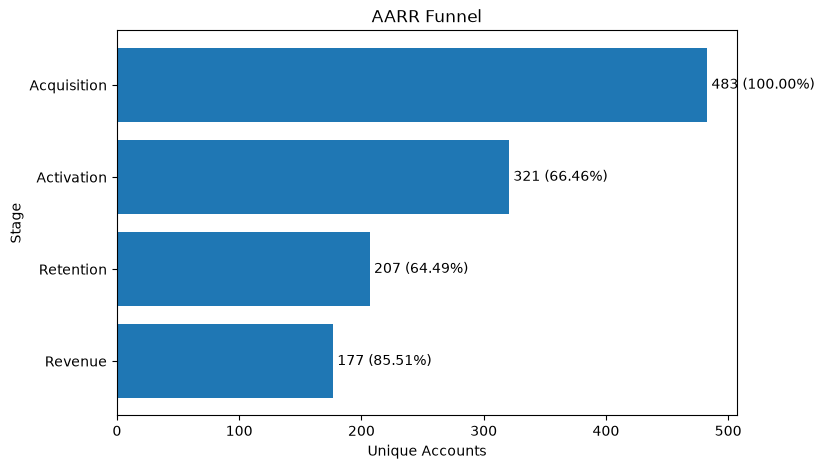

전환율이 가장 낮은 구간
Activation -> Retention
전환율: 64.49%
이탈률: 35.51%

이탈 원인 가설 1
가설: 첫 구독 이후 사용자가 핵심 기능의 가치를 충분히 경험하지 못했을 수 있다.
검증 방법: Retention 도달 계정과 미도달 계정의 기능 사용 횟수와 사용 기능 종류를 비교한다.

이탈 원인 가설 2
가설: 초기 기능 사용 이후 지속적으로 제품을 사용할 동기가 부족할 수 있다.
검증 방법: 첫 30일의 기능 사용 빈도와 30일 이후 재사용 여부의 관계를 분석한다.


In [3]:
# 필수 2 코드를 작성하세요.
plot_data = funnel_summary.copy()

plt.figure(figsize=(8, 5))

bars = plt.barh(
    plot_data.index,
    plot_data["고유 계정 수"]
)

plt.xlabel("Unique Accounts")
plt.ylabel("Stage")
plt.title("AARR Funnel")

for bar, count, rate in zip(
    bars,
    plot_data["고유 계정 수"],
    plot_data["전 단계 대비 전환율"]
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {count:,} ({rate * 100:.2f}%)",
        va="center"
    )

plt.gca().invert_yaxis()
plt.show()


conversion_rates = funnel_summary[
    "전 단계 대비 전환율"
].iloc[1:]

lowest_stage = conversion_rates.idxmin()
lowest_rate = conversion_rates.min()

stages = funnel_summary.index.tolist()

lowest_index = stages.index(lowest_stage)
previous_stage = stages[lowest_index - 1]

dropoff_rate = 1 - lowest_rate

print("전환율이 가장 낮은 구간")
print(previous_stage, "->", lowest_stage)
print(f"전환율: {lowest_rate * 100:.2f}%")
print(f"이탈률: {dropoff_rate * 100:.2f}%")

print("\n이탈 원인 가설 1")

if lowest_stage == "Activation":
    print("가설: 가입 후 첫 구독을 시작하는 과정이 복잡하거나 구독 혜택이 충분히 전달되지 않았을 수 있다.")
    print("검증 방법: 미활성화 계정의 가입 후 행동 로그와 구독 시작 화면의 이탈 지점을 분석한다.")

elif lowest_stage == "Retention":
    print("가설: 첫 구독 이후 사용자가 핵심 기능의 가치를 충분히 경험하지 못했을 수 있다.")
    print("검증 방법: Retention 도달 계정과 미도달 계정의 기능 사용 횟수와 사용 기능 종류를 비교한다.")

elif lowest_stage == "Revenue":
    print("가설: 유지 사용자는 존재하지만 유료 요금제의 가격이나 혜택이 결제 전환에 충분하지 않을 수 있다.")
    print("검증 방법: 체험판과 유료 구독 계정의 기능 사용량, 요금제, MRR 데이터를 비교한다.")

print("\n이탈 원인 가설 2")

if lowest_stage == "Activation":
    print("가설: 가입한 계정이 30일 이내에 구독을 시작할 만큼 초기 온보딩이 충분하지 않을 수 있다.")
    print("검증 방법: 가입일부터 첫 구독까지 걸린 기간을 분석하고 구독을 시작하지 않은 계정과 비교한다.")

elif lowest_stage == "Retention":
    print("가설: 초기 기능 사용 이후 지속적으로 제품을 사용할 동기가 부족할 수 있다.")
    print("검증 방법: 첫 30일의 기능 사용 빈도와 30일 이후 재사용 여부의 관계를 분석한다.")

elif lowest_stage == "Revenue":
    print("가설: 특정 요금제에서 유료 전환 장벽이 상대적으로 높을 수 있다.")
    print("검증 방법: plan_tier별 Revenue 전환율을 비교하여 특정 요금제에 이탈이 집중되는지 확인한다.")

### 필수 2 답변 작성란

**Q1.** 전 단계 대비 전환율이 가장 낮은 단계와 이탈 구간은 어디인가요?
  - Retention 단계가 64.5%로 가장 낮음. 이탈 구간은 Activaition > Retention

**Q2.** 퍼널 결과만으로 이탈의 원인을 확정할 수 있나요?  
  - 없다. 퍼널은 계정이 ㅁ낳이 줄어든 구간을 보여 준다.
  - 기능, 오류, 지원 등에 대한 원인은 추가적인 데이터 분석을 통해 확인할 수 있다..

**Q3.** 해당 구간을 개선하기 위해 어떤 데이터를 추가로 확인할 수 있나요?
  - 오류 수, 오류 종류, 고객 지원, 프로모션 등을 확인할 수 있습닏,ㅏ

---

## 과제 1. 평가 문항 기반 독립 과제

### 문제 3-1. 첫 구독 요금제별 퍼널 비교와 개선 가설 제안하기

#### 문제 설명

첫 구독의 plan_tier별로 Acquisition → Activation → Retention → Revenue 단계의 계정 수와 전환율을 비교하세요. 이탈이 집중된 구간을 찾고, 개선 가설과 검증 방법을 제안하세요.

> 필수 문제의 단계 정의와 집계·전환율 계산·시각화 절차를 그대로 활용합니다. Referral은 관련 행동 기록이 없어 분석에서 제외합니다.

#### 요구사항

1. 원시 계정·구독·기능 사용 데이터를 연결하여 funnel_base와 단계 도달 여부를 만드는 코드를 제출물에 포함하세요. 필수 문제에서 작성한 코드를 재사용해도 됩니다.
2. 첫 구독의 plan_tier별로 Acquisition, Activation, Retention, Revenue의 고유 계정 수를 집계하세요. 각 단계에는 이전 단계에 도달한 계정만 포함하세요.
3. 요금제별로 다음 값을 계산하여 plan_funnel을 만드세요.
- 구간 전환율 = 현재 단계 계정 수 ÷ 이전 단계 계정 수 × 100
- 구간 이탈률 = 100 − 구간 전환율
- 구간 이탈 계정 수 = 이전 단계 계정 수 − 현재 단계 계정 수
- 첫 단계는 비교할 이전 단계가 없으므로 구간 지표를 빈 값으로 두세요. 이전 단계 계정 수가 0이면 전환율·이탈률을 계산 불가로 표시하세요.
4. 요금제별로 단계별 고유 계정 수를 가로 막대그래프로 시각화하고, 각 단계의 구간 전환율을 함께 표시하세요.
5. 첫 단계를 제외하고 전환율이 가장 낮은 요금제·구간 조합을 찾으세요. 해당 구간의 전환율·이탈률·이탈 계정 수를 근거로 이탈 집중 구간을 설명하세요.
6. 요금제별 최종 Revenue 도달률을 계산하여 plan_summary로 출력하세요. 가장 높은 요금제와 낮은 요금제의 차이를 %p로 계산하세요.
- 최종 Revenue 도달률 = Revenue 계정 수 ÷ Acquisition 계정 수 × 100
7. 우선 점검할 구간에 대해 “어떤 원인 때문에 이탈하며, 어떤 변경을 하면 전환율이 개선될 것이다”라는 개선 가설을 한 가지 작성하세요.
  - Enterprise 사용자가 지속 사용 가치를 느끼지 못해 이탈할 수 있으므로, 재사용 유도 기능을 강화하면 전환율이 개선될 수 있다.
8. 가설을 확인하기 위한 추가 데이터 2가지와 검증 방법을 설명하세요. 어떤 대상을 비교하고 어떤 지표로 개선 여부를 판단할지 포함하세요. 실제 실험이나 통계 검정은 수행하지 않아도 됩니다.
  - 기능 사용 빈도와 재방문 간격을 확인한다.  
  - 개선 전후의 Activation → Retention 전환율을 비교해 효과를 판단한다.
#### 해석 질문

Q1. 전환율이 가장 낮은 요금제와 구간은 무엇이며, 전환율·이탈률·이탈 계정 수는 얼마인가요?

Q2. 최종 Revenue 도달률이 가장 높은 요금제와 낮은 요금제는 무엇이며, 차이는 몇 %p인가요?

Q3. 우선 점검할 구간에 대한 개선 가설은 무엇이며, 어떤 데이터와 방법으로 검증할 수 있나요?

Q4. 요금제별 차이만으로 요금제가 이탈의 원인이라고 결론 내릴 수 있나요?

#### 제출 결과

- 원시 데이터 연결 및 단계 도달 여부 구성 코드
- plan_funnel: 단계별 계정 수·전환율·이탈률·이탈 계정 수
- 요금제별 퍼널 그래프
- 이탈 집중 구간과 수치 근거
- plan_summary: 최종 Revenue 도달률과 최고·최저 차이
- 개선 가설·추가 확인 데이터 2가지·검증 방법
- Q1~Q4 답변

,plan_tier,stage,계정 수,구간 전환율(%),구간 이탈률(%),구간 이탈 계정 수
0,Basic,Acquisition,162,,,
1,Basic,Activation,102,62.96%,37.04%,60
2,Basic,Retention,69,67.65%,32.35%,33
3,Basic,Revenue,57,82.61%,17.39%,12
4,Pro,Acquisition,160,,,
5,Pro,Activation,102,63.75%,36.25%,58
6,Pro,Retention,67,65.69%,34.31%,35
7,Pro,Revenue,60,89.55%,10.45%,7
8,Enterprise,Acquisition,161,,,
9,Enterprise,Activation,117,72.67%,27.33%,44


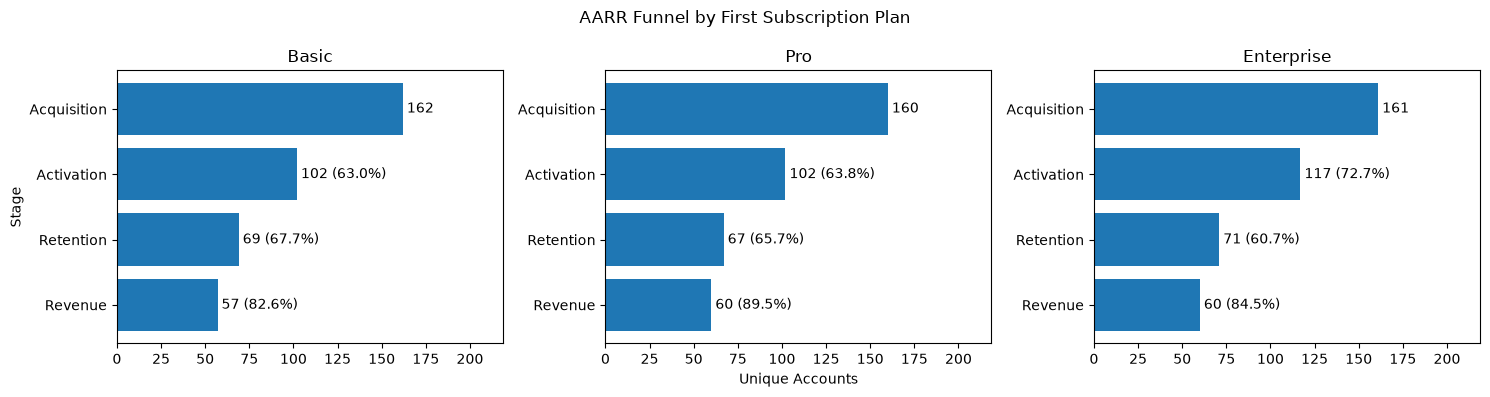

전환율이 가장 낮은 조합
요금제: Enterprise / 구간: Activation -> Retention
전환율: 60.68%, 이탈률: 39.32%, 이탈 계정 수: 46


stage,Acquisition,Revenue,최종 Revenue 도달률(%)
plan_tier,,,
Pro,160,60,37.50
Enterprise,161,60,37.27
Basic,162,57,35.19


최고: Pro 37.50% / 최저: Basic 35.19% / 차이: 2.31%p


In [4]:
# 과제 1 코드를 작성하세요.
accounts = pd.read_csv("ravenstack_accounts.csv", parse_dates=["signup_date"])
subscriptions = pd.read_csv("ravenstack_subscriptions.csv", parse_dates=["start_date", "end_date"])
feature_usage = pd.read_csv("ravenstack_feature_usage.csv", parse_dates=["usage_date"])

first_sub = (
    subscriptions.sort_values("start_date")
    .drop_duplicates("account_id")
    [["account_id", "subscription_id", "start_date", "end_date", "is_trial", "mrr_amount", "plan_tier"]]
)

usage = feature_usage.merge(first_sub, on="subscription_id")
valid_usage = usage[
    (usage["usage_date"] >= usage["start_date"])
    & (usage["end_date"].isna() | (usage["usage_date"] <= usage["end_date"]))
]
observation_cutoff = feature_usage["usage_date"].max() - pd.Timedelta(days=30)
retained_ids = set(
    valid_usage.loc[valid_usage["usage_date"] >= valid_usage["start_date"] + pd.Timedelta(days=30), "account_id"]
)

funnel_base = (
    accounts.loc[accounts["signup_date"] <= observation_cutoff, ["account_id", "signup_date"]]
    .merge(first_sub, on="account_id", how="left")
)
funnel_base["Acquisition"] = True
funnel_base["Activation"] = (
    funnel_base["start_date"].between(funnel_base["signup_date"], funnel_base["signup_date"] + pd.Timedelta(days=30))
)
funnel_base["Retention"] = funnel_base["Activation"] & funnel_base["account_id"].isin(retained_ids)
funnel_base["Revenue"] = (
    funnel_base["Retention"] & (funnel_base["is_trial"] == False) & (funnel_base["mrr_amount"] > 0)
)

stages = ["Acquisition", "Activation", "Retention", "Revenue"]
plans = ["Basic", "Pro", "Enterprise"]

funnel_log = (
    funnel_base.melt(id_vars=["account_id", "plan_tier"], value_vars=stages, var_name="stage", value_name="reached")
    .query("reached")
)
plan_counts = (
    funnel_log.groupby(["plan_tier", "stage"])["account_id"].nunique()
    .unstack()
    .reindex(index=plans, columns=stages, fill_value=0)
)

plan_funnel = plan_counts.stack().reset_index(name="계정 수")
prev = plan_funnel.groupby("plan_tier")["계정 수"].shift(1)
plan_funnel["구간 전환율(%)"] = (plan_funnel["계정 수"] / prev.replace(0, float("nan")) * 100).round(2)
plan_funnel["구간 이탈률(%)"] = (100 - plan_funnel["구간 전환율(%)"]).round(2)
plan_funnel["구간 이탈 계정 수"] = prev - plan_funnel["계정 수"]

plan_funnel_print = plan_funnel.copy()
for col in ["구간 전환율(%)", "구간 이탈률(%)"]:
    plan_funnel_print[col] = plan_funnel_print[col].map(lambda x: f"{x:.2f}%" if pd.notna(x) else "")
    plan_funnel_print.loc[prev.eq(0), col] = "계산 불가"
plan_funnel_print["구간 이탈 계정 수"] = plan_funnel_print["구간 이탈 계정 수"].map(
    lambda x: "" if pd.isna(x) else int(x)
)
display(plan_funnel_print)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for ax, plan in zip(axes, plans):
    d = plan_funnel[plan_funnel["plan_tier"] == plan]
    bars = ax.barh(d["stage"], d["계정 수"])
    for bar, n, r in zip(bars, d["계정 수"], d["구간 전환율(%)"]):
        label = f" {n} ({r:.1f}%)" if pd.notna(r) else f" {n}"
        ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, label, va="center")
    ax.set_title(plan)
    ax.invert_yaxis()
axes[0].set_ylabel("Stage")
axes[1].set_xlabel("Unique Accounts")
axes[0].set_xlim(0, plan_funnel["계정 수"].max() * 1.35)
fig.suptitle("AARR Funnel by First Subscription Plan")
plt.tight_layout()
plt.show()

section = plan_funnel.dropna(subset=["구간 전환율(%)"])
lowest = section.loc[section["구간 전환율(%)"].idxmin()]
previous_stage = stages[stages.index(lowest["stage"]) - 1]
print("전환율이 가장 낮은 조합")
print(f"요금제: {lowest['plan_tier']} / 구간: {previous_stage} -> {lowest['stage']}")
print(f"전환율: {lowest['구간 전환율(%)']:.2f}%, 이탈률: {lowest['구간 이탈률(%)']:.2f}%, "
      f"이탈 계정 수: {int(lowest['구간 이탈 계정 수'])}")

plan_summary = plan_counts[["Acquisition", "Revenue"]].copy()
plan_summary["최종 Revenue 도달률(%)"] = (plan_summary["Revenue"] / plan_summary["Acquisition"] * 100).round(2)
plan_summary = plan_summary.sort_values("최종 Revenue 도달률(%)", ascending=False)
display(plan_summary)

rate = plan_summary["최종 Revenue 도달률(%)"]
print(f"최고: {rate.idxmax()} {rate.max():.2f}% / 최저: {rate.idxmin()} {rate.min():.2f}% / "
      f"차이: {rate.max() - rate.min():.2f}%p")

### 과제 1 답변 작성란

Q1. 전환율이 가장 낮은 요금제와 구간은 무엇이며, 전환율·이탈률·이탈 계정 수는 얼마인가요?
  - 전환율이 가장 낮은 조합은 Enterprise의 Activation > Retention 구간이다.
  - 전환율은 60.68%, 이탈률은 39.32%, 이탈 계정 수는 46개이다.

Q2. 최종 Revenue 도달률이 가장 높은 요금제와 낮은 요금제는 무엇이며, 차이는 몇 %p인가요?
  - 최종 Revenue 도달률은 Pro가 37.50%로 가장 높고 Basic이 35.19%로 가장 낮다.
  - 차이는 2.31%p이다.

Q3. 우선 점검할 구간에 대한 개선 가설은 무엇이며, 어떤 데이터와 방법으로 검증할 수 있나요?
  - 지속 사용 가치를 충분히 느끼지 못해 이탈할 수 있으므로 재사용 유도 기능을 강화한다.
  - Enterprise 신규 계정을 무작위로 두 그룹으로 나누어 한쪽에만 재사용 유도 기능을 적용하고 두 그룹의 Activation > Retention 전환율(첫 구독 30일 후 유효 사용 계정 수 / Activation 계정 수)을 비교해 검증한다.

Q4. 요금제별 차이만으로 요금제가 이탈의 원인이라고 결론 내릴 수 있나요?
  - 없다. 요금제는 고객이 직접 선택한 것이라 계정 규모, 산업, 유입 경로 같은 다른 특성이 함께 섞여 있을 가능성이 있다.

---

## 실습 마무리

1. 이번 분석에서는 각 AARR 단계를 어떤 조건으로 정의했나요?
  - Acquisition(유입), Activation(활성화), Retention(재구독), Revenue(수익, 유료전환)

2. 단계별 고유 계정 수는 어떤 코드로 집계했나요?
  - group by('stage")['account_id'].unuique()

3. 전 단계 대비 전환율과 전체 대비 전환율은 각각 무엇을 보여주나요?
  - 전자는 바로 이전 단계에서 유지(이동)한 비율
  - 후자는 Acquisition 계정 중 현재 단계까지 남은 비율

4. 어느 구간에서 이탈이 가장 집중되었나요?
  - 64.5%, Activation > Retention 구간

5. 퍼널 수치와 이탈 원인을 왜 구분해야 하나요?
  - 퍼널은 이탈 단계를 보여 주지만 이탈의 직접적인 원인은 추가 데이터 검증이 필요하다.

6. Referral 단계를 이번 분석에서 제외한 이유는 무엇인가요?
  - 